# ANALISIS EXPLORATORIO FINAL - RETO 06 LIBERE

### ANALISIS DF COMPLETO

In [160]:
#Cargar librerias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [117]:
#Cargar datos
path = os.path.join('Datos', 'Limpios', 'df_final.csv')
df = pd.read_csv(path)

In [118]:
#Columnas
df.columns

Index(['lead_time', 'lenght_of_stay', 'checkin_month', 'checkin_day',
       'adult_count', 'child_count', 'origin', 'travel_agency_name',
       'requested_category', 'requested_category_name', 'asset', 'asset_type',
       'brand', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'returning_inhabitant', 'recurrence',
       'libere_community', 'bought_products', 'product_count',
       'reservation_net_value', 'total_adr', 'status', 'cancellation_reason',
       'cancellation_lead_time', 'City', 'Reserva_Dia_Semana',
       'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia',
       'Estacion_Reserva', 'zona_roja_mes', 'momento_checkin',
       'total_personas_adult_y_niños', 'ratio_formularios',
       'reservation_checkin_month_diff', 'estancia_en_festivo',
       'estancia_en_finde', 'mes_checkin_numerico'],
      dtype='object')

In [119]:
# Tipo de columnas:
print(df.dtypes)

lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                          int64
libere_community                   object
bought_products                   

In [120]:
# Tamaño
df.shape

(53747, 44)

In [121]:
# Visualizar primeras 5 instancias
print(df.head(5))

   lead_time  lenght_of_stay checkin_month checkin_day  adult_count  \
0         36               1       January      Sunday            1   
1         11               9       January      Sunday            1   
2        102               6       January      Sunday            2   
3         99               1       January      Sunday            2   
4         75               1       January      Sunday            4   

   child_count           origin travel_agency_name requested_category  \
0            0  channel_manager        Booking.com         Hostel bed   
1            0  channel_manager        Booking.com         Hostel bed   
2            4  channel_manager        Booking.com        Hostel room   
3            2  channel_manager        Booking.com        Hostel room   
4            0  channel_manager        Booking.com        Hostel room   

                     requested_category_name  ... Estacion_Estancia  \
0  6 bed community room with shared bathroom  ...            Wi

In [137]:
#Crear paleta de colores
paleta =["#F48A48","#6F4E37","#EBB68D","#391704", "#FF4704"]

GRAFICOS

1º GRAFICO: Mes de check-in vs duración media (GENERAL)

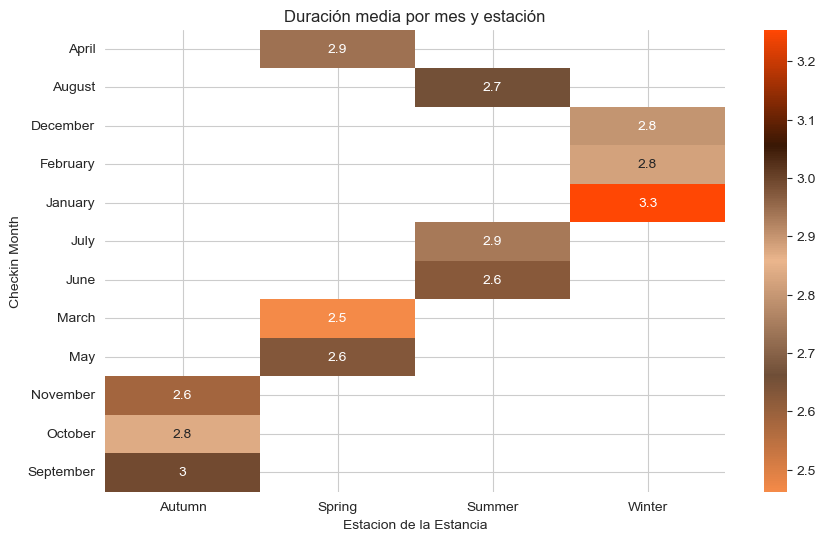

In [123]:
# Paleta personalizada:
mi_cmap = LinearSegmentedColormap.from_list(
    "mi_paleta",
    list(paleta))

pivot = df.pivot_table(
    values='lenght_of_stay',
    index='checkin_month',
    columns='Estacion_Estancia',
    aggfunc='mean')

#Grafico
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap=mi_cmap)
plt.title("Duración media por mes y estación")
plt.ylabel("Checkin Month")
plt.xlabel("Estacion de la Estancia")
plt.show()


2º GRAFICO: Distribución del Lead Time (reserva anticipada) (GENERAL)

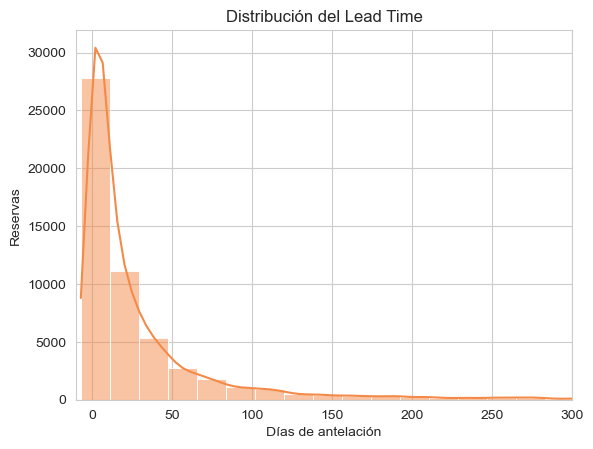

In [124]:
sns.histplot(df["lead_time"], bins=50, kde=True, color = paleta[0])
plt.title("Distribución del Lead Time")
plt.xlabel("Días de antelación")
plt.ylabel("Reservas")
plt.xlim(-10,300)
plt.show()

3º GRAFICO: Distribución del Lead Time según rango de recurrencia (GENERAL)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\406197897.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby('recurrence_range')['lead_time'].mean().reset_index()
C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\406197897.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\406197897.py:16: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


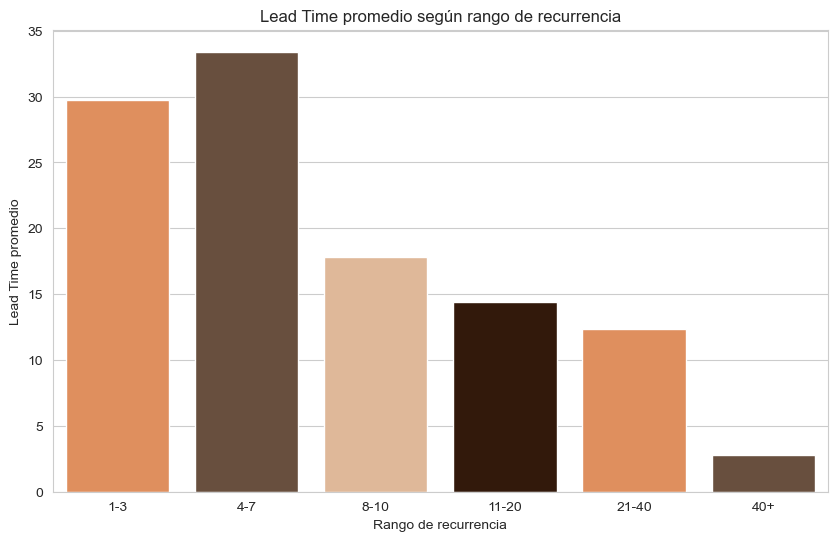

In [125]:
# Definir los rangos incluyendo >40
bins = [0, 3, 7, 10, 20, 40, np.inf]
labels = ['1-3', '4-7', '8-10', '11-20', '21-40', '40+']

# Crear columna con rango
df['recurrence_range'] = pd.cut(df['recurrence'], bins=bins, labels=labels, right=True)

# Agrupar por rango y calcular la media
df_grouped = df.groupby('recurrence_range')['lead_time'].mean().reset_index()

# Paleta personalizada
paleta = ["#F48A48","#6F4E37","#EBB68D","#391704"]

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_grouped,
    x='recurrence_range',
    y='lead_time',
    palette=paleta  # Se repetirá automáticamente para 6 rangos
)
plt.title("Lead Time promedio según rango de recurrencia")
plt.xlabel("Rango de recurrencia")
plt.ylabel("Lead Time promedio")
plt.show()



4º GRAFICO : Mes vs fin de semana (GENERAL)

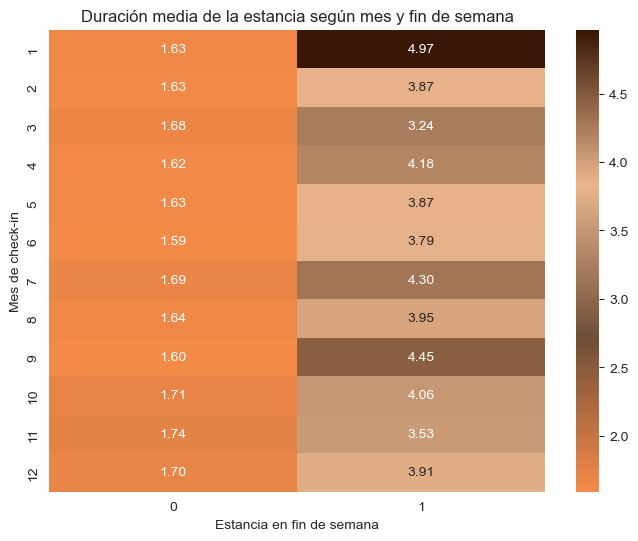

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Pivot table
pivot = df.pivot_table(
    values="lenght_of_stay",
    index="mes_checkin_numerico",
    columns="estancia_en_finde",
    aggfunc="mean"
)

# Crear colormap con tu paleta
custom_cmap = LinearSegmentedColormap.from_list("custom_palette", paleta)

# Graficar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap
)

plt.title("Duración media de la estancia según mes y fin de semana")
plt.xlabel("Estancia en fin de semana")
plt.ylabel("Mes de check-in")
plt.show()


5º GRAFICO: Proporcion de reservas confirmadas vs canceladas (CANCELACION)

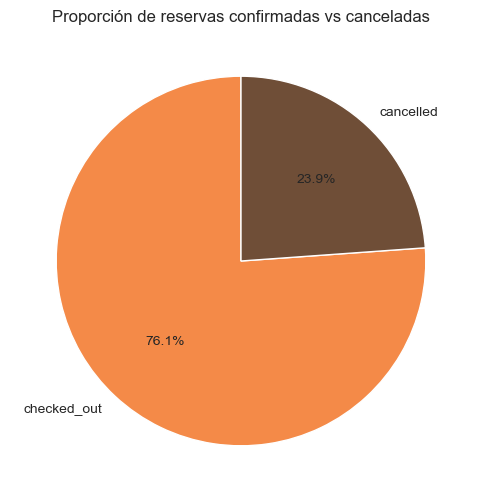

In [127]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=list(paleta)
)
plt.title("Proporción de reservas confirmadas vs canceladas")
plt.show()



6º GRAFICO: Reservas por mes y día de la semana (GENERAL)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\4008695211.py:2: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


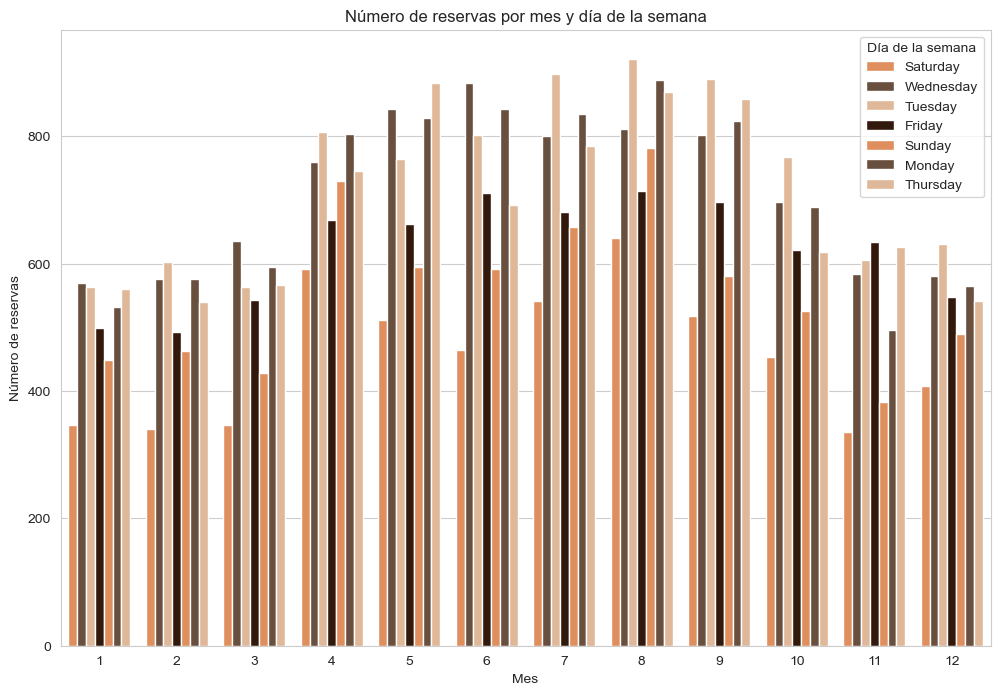

In [128]:
plt.figure(figsize=(12,8))
sns.countplot(
    data=df,
    x="mes_checkin_numerico",
    hue="Reserva_Dia_Semana",
    palette=paleta
)
plt.title("Número de reservas por mes y día de la semana")
plt.xlabel("Mes")
plt.ylabel("Número de reservas")
plt.legend(title="Día de la semana")
plt.show()


7º GRAFICO: Reservas por temporada + valor medio (GENERAL)

In [129]:
print(df["reservation_net_value"])

0         15.92
1        117.78
2        755.65
3        186.37
4         77.02
          ...  
53742     169.6
53743     169.6
53744    647.28
53745    732.73
53746    343.64
Name: reservation_net_value, Length: 53747, dtype: object


C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\3818919296.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


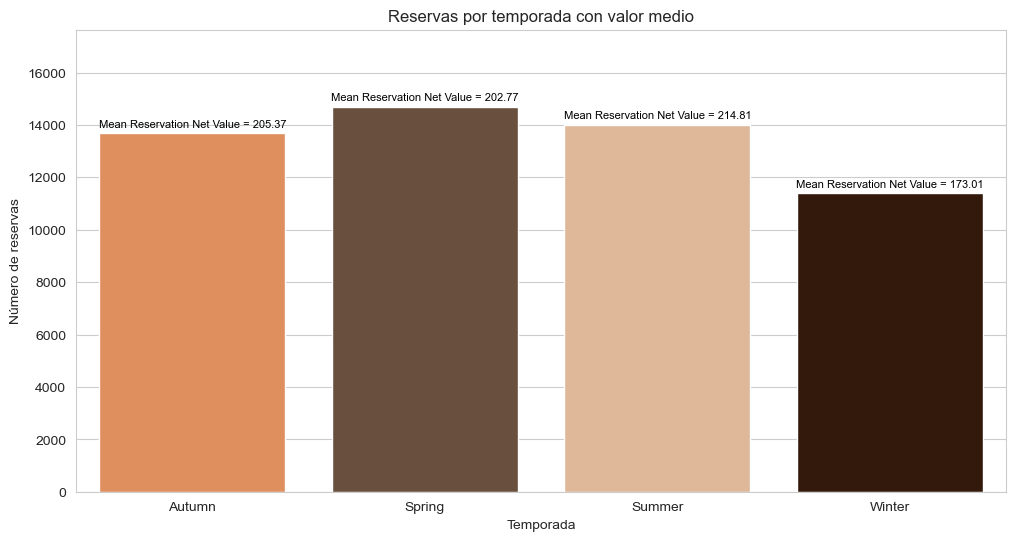

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Convertir la columna a numérico ---
df['reservation_net_value'] = pd.to_numeric(df['reservation_net_value'], errors='coerce')

# --- Agrupar por temporada ---
season_group = df.groupby('Estacion_Reserva').agg(
    reservas=('status', 'count'),
    valor_medio=('reservation_net_value', 'mean')
).reset_index()

# --- Definir paleta de colores ---
colores = paleta[:len(season_group)]  # asegurarse de que coincida con las categorías

# --- Graficar barras con etiquetas descriptivas ---
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=season_group,
    x='Estacion_Reserva',
    y='reservas',
    palette=colores
)

# Agregar etiquetas con el valor medio sobre cada barra
for i, row in season_group.iterrows():
    ax.text(
        i,  # posición x de la barra
        row['reservas'] * 1.01234,  # posición y encima de la barra
        f"Mean Reservation Net Value = {row['valor_medio']:.2f}",  # etiqueta descriptiva
        ha='center', va='bottom', fontsize=8, color='black'
    )

plt.title("Reservas por temporada con valor medio")
plt.xlabel("Temporada")
plt.ylabel("Número de reservas")
plt.ylim(0, season_group['reservas'].max()*1.20)  # dar espacio para las etiquetas
plt.show()



8º GRAFICO: Reservas en festivos vs no festivos por estado

In [131]:
GRAFICOS SOBRE ZONA ROJA. CIUDADES. EN QUE CIUDAD ES EN LA QUE MAS SE RESERVA Y EN LA QUE MAS SE CANCELA

SyntaxError: invalid syntax (953527138.py, line 1)

In [ ]:
#CADA MES COMO VA AUMENTANDO EL PORCEAJE DE RESERVAS Y EL PORCENTJAE DE CANCELACIONES(POR CIUDADES)

In [ ]:
“Reservas y cancelaciones por día de la semana” – barras o heatmap mostrando qué días hay más cancelaciones.

“Lead time promedio vs cancelaciones” – scatter plot mostrando relación entre anticipación de reserva y cancelación.

“Distribución de estancia por ciudad” – boxplot mostrando variabilidad de días de estancia según ciudad.

“Valor medio de reservas por agencia de viajes” – barras ordenadas descendentes para ver agencias más lucrativas.

“Ratio de formularios completados vs cancelaciones” – scatter con tamaño de punto según número de personas en reserva.

“Reservas recurrentes vs nuevas por mes” – línea mostrando tendencia de clientes que repiten.

“Promedio de ADR vs tipo de habitación” – violin plot o boxplot para comparar precios según categoría solicitada.

“Porcentaje de cancelaciones según estación de reserva” – barras apiladas por estación (Navidad, verano, etc.).

“Ocupación vs disponibilidad de unidades por activo” – heatmap para ver activos más saturados.

“Mapa de ciudades con mayor porcentaje de cancelaciones” – choropleth o scatter map si tienes coordenadas o nombres de ciudad.

“Reservas por segmento de negocio y tipo de tarifa” – stacked bar chart mostrando combinaciones más frecuentes.

“Tiempo hasta cancelación vs valor de reserva” – scatter con gradiente de color según ciudad.

“Distribución de total personas por mes y ciudad” – heatmap para ver picos de ocupación familiar.

“Efecto de días festivos en lead time promedio” – line plot comparando lead time en festivos vs no festivos.

“Cancelaciones por motivo y ciudad” – barras horizontales ordenadas para identificar patrones.

9º GRAFICO: ¿Dónde se reserva más y dónde se cancela más? (CANCELACION)

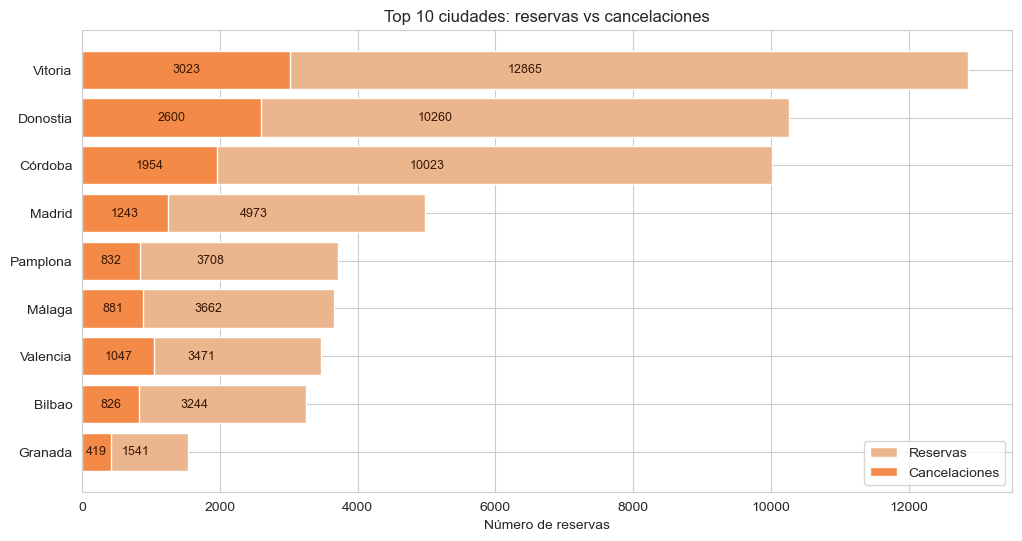

In [132]:
city_group = (
    df.groupby("City")
    .agg(
        reservas=("status", "count"),
        cancelaciones=("status", lambda x: (x=="cancelled").sum())
    )
    .assign(ratio_cancelacion=lambda x: x.cancelaciones / x.reservas)
    .sort_values("reservas", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars_reservas = plt.barh(
    city_group.index,
    city_group["reservas"],
    color=paleta[2],
    label="Reservas"
)

bars_cancelaciones = plt.barh(
    city_group.index,
    city_group["cancelaciones"],
    color=paleta[0],
    label="Cancelaciones"
)

# Etiquetas centradas
plt.bar_label(bars_reservas, labels=city_group["reservas"], label_type="center", color=paleta[3], fontsize=9)
plt.bar_label(bars_cancelaciones, labels=city_group["cancelaciones"], label_type="center", color=paleta[3], fontsize=9)

plt.xlabel("Número de reservas")
plt.title("Top 10 ciudades: reservas vs cancelaciones")
plt.legend()
plt.gca().invert_yaxis()
plt.show()


10º GRAFICO: “Zona roja” vs comportamiento real (cancelación)
porcentaje de cancelación
“De los que estaban en zona roja, ¿qué % canceló?” (CANCELACION)

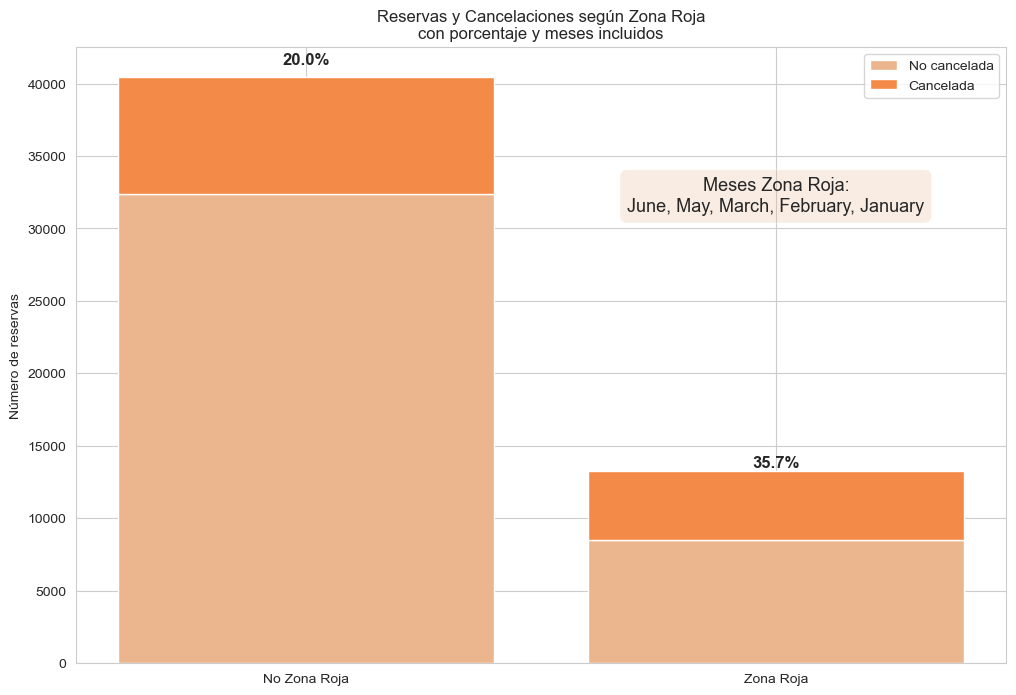

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Lista de meses de Zona Roja que ya calculaste
meses_zona_roja = ['June', 'May', 'March', 'February', 'January']

# Crear variable auxiliar: Cancelada / No cancelada
df["estado_simple"] = np.where(df["status"] == "cancelled", "Cancelada", "No cancelada")

# Agrupar por Zona Roja y contar reservas
zona_estado = (
    df.groupby(["zona_roja_mes", "estado_simple"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

zona_estado["zona"] = zona_estado["zona_roja_mes"].map({0:"No Zona Roja", 1:"Zona Roja"})

# Calcular porcentaje de cancelación
zona_estado["porcentaje_cancelacion"] = zona_estado["Cancelada"] / (zona_estado["Cancelada"] + zona_estado["No cancelada"]) * 100

# Crear gráfico
plt.figure(figsize=(12,8))

# Barras apiladas: No canceladas + Canceladas
plt.bar(
    zona_estado["zona"],
    zona_estado["No cancelada"],
    label="No cancelada",
    color=paleta[2]
)
plt.bar(
    zona_estado["zona"],
    zona_estado["Cancelada"],
    bottom=zona_estado["No cancelada"],
    label="Cancelada",
    color=paleta[0]
)

# Etiquetas de porcentaje encima de cada barra
for i, row in zona_estado.iterrows():
    total = row["No cancelada"] + row["Cancelada"]
    plt.text(
        i,
        total + total*0.02,
        f"{row['porcentaje_cancelacion']:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# Etiquetas de meses Zona Roja
texto_meses = "Meses Zona Roja:\n" + ", ".join(meses_zona_roja)
plt.text(
    1,  # posición barra Zona Roja
    zona_estado.iloc[1]["No cancelada"] + zona_estado.iloc[1]["Cancelada"]*5,
    texto_meses,
    ha="center",
    va="center",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.4", facecolor=paleta[2], alpha=0.25)
)

plt.ylabel("Número de reservas")
plt.title("Reservas y Cancelaciones según Zona Roja\ncon porcentaje y meses incluidos")
plt.legend()
plt.show()


11º GRAFICO: Momento del check-in vs probabilidad de cancelación (CANCELACION)

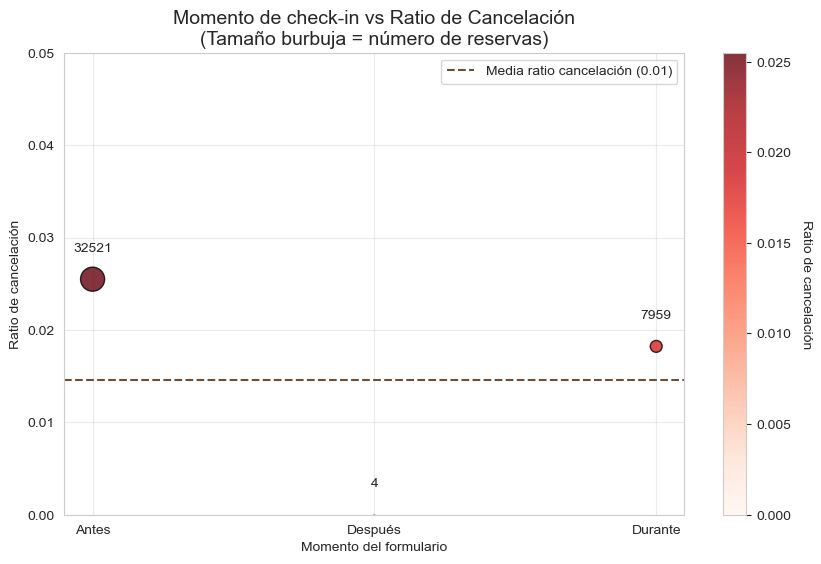

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Agrupar por momento_checkin
momento_group = (
    df.groupby("momento_checkin")
    .agg(
        ratio_cancelacion=("status", lambda x: (x=="cancelled").mean()),
        reservas=("status", "count")
    )
    .reset_index()
)

# Escalar tamaño de burbujas
size_scale = 300
sizes = momento_group["reservas"] / momento_group["reservas"].max() * size_scale

# Plot profesional
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    x=momento_group["momento_checkin"],
    y=momento_group["ratio_cancelacion"],
    s=sizes,
    c=momento_group["ratio_cancelacion"],  # ahora matplotlib sabe el valor
    cmap="Reds",                          # colormap
    alpha=0.8,
    edgecolor="black"
)

# Etiquetas con número de reservas
for _, row in momento_group.iterrows():
    plt.text(
        row["momento_checkin"],
        row["ratio_cancelacion"] + 0.003,
        f"{row['reservas']}",
        ha='center',
        fontsize=10
    )

# Línea media del ratio de cancelación
media_ratio = momento_group["ratio_cancelacion"].mean()
plt.axhline(media_ratio, color=paleta[1], linestyle="--", label=f"Media ratio cancelación ({media_ratio:.2f})")

# Colorbar automático
cbar = plt.colorbar(scatter)
cbar.set_label("Ratio de cancelación", rotation=270, labelpad=15)

# Títulos y etiquetas
plt.title("Momento de check-in vs Ratio de Cancelación\n(Tamaño burbuja = número de reservas)", fontsize=14)
plt.xlabel("Momento del formulario")
plt.ylabel("Ratio de cancelación")
plt.ylim(0, momento_group["ratio_cancelacion"].max() + 0.1)
plt.grid(alpha=0.4)
plt.ylim(0,0.05)
plt.legend()
plt.show()


12º GRAFICO: Evolución mensual del % de cancelación por ciudad (CANCELACION)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\1242250834.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df["City"].isin(top_cities)]


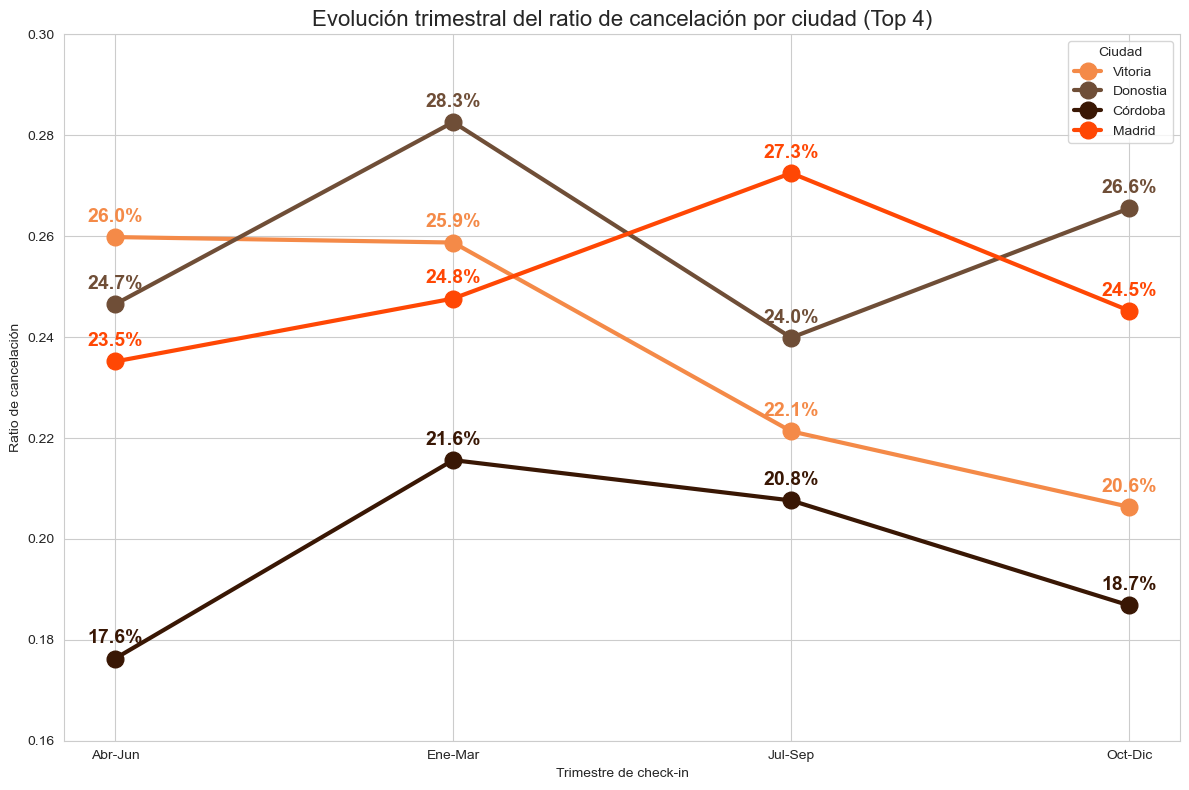

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Nueva paleta
colores_usar = [paleta[0], paleta[1], paleta[3], paleta[4]]  # colores 1,2,4,5

# Top 4 ciudades
top_cities = df["City"].value_counts().head(4).index

# Crear columna de trimestre
def asignar_trimestre(mes):
    if mes in [1,2,3]:
        return "Ene-Mar"
    elif mes in [4,5,6]:
        return "Abr-Jun"
    elif mes in [7,8,9]:
        return "Jul-Sep"
    else:
        return "Oct-Dic"

df["Trimestre"] = df["mes_checkin_numerico"].astype(int).apply(asignar_trimestre)

# Agrupar por ciudad y trimestre
df_city_quarter = (
    df[df["City"].isin(top_cities)]
    .groupby(["City","Trimestre"])
    .apply(lambda x: (x["status"]=="cancelled").mean())
    .reset_index(name="ratio_cancelacion")
)

# Plot
plt.figure(figsize=(12,8))
sns.set_style("whitegrid")

for i, city in enumerate(top_cities):
    color = colores_usar[i % len(colores_usar)]
    subset = df_city_quarter[df_city_quarter["City"]==city]
    
    plt.plot(
        subset["Trimestre"],
        subset["ratio_cancelacion"],
        marker="o",
        linewidth=3,
        markersize=12,
        label=city,
        color=color
    )
    
    # Etiquetas de porcentaje del mismo color que la línea
    for j, row in subset.iterrows():
        plt.text(
            row["Trimestre"],
            row["ratio_cancelacion"] + 0.003,
            f"{row['ratio_cancelacion']*100:.1f}%",
            ha='center',
            fontsize=14,
            color=color,
            fontweight='bold'
        )

plt.title("Evolución trimestral del ratio de cancelación por ciudad (Top 4)", fontsize=16)
plt.ylabel("Ratio de cancelación")
plt.xlabel("Trimestre de check-in")
plt.legend(title="Ciudad")
plt.ylim(0.16,0.30)
plt.tight_layout()
plt.show()


13º GRAFICO: Festivos + Zona roja = ¿doble riesgo? (Ratio cancelación + nº reservas) (CANCELACION)

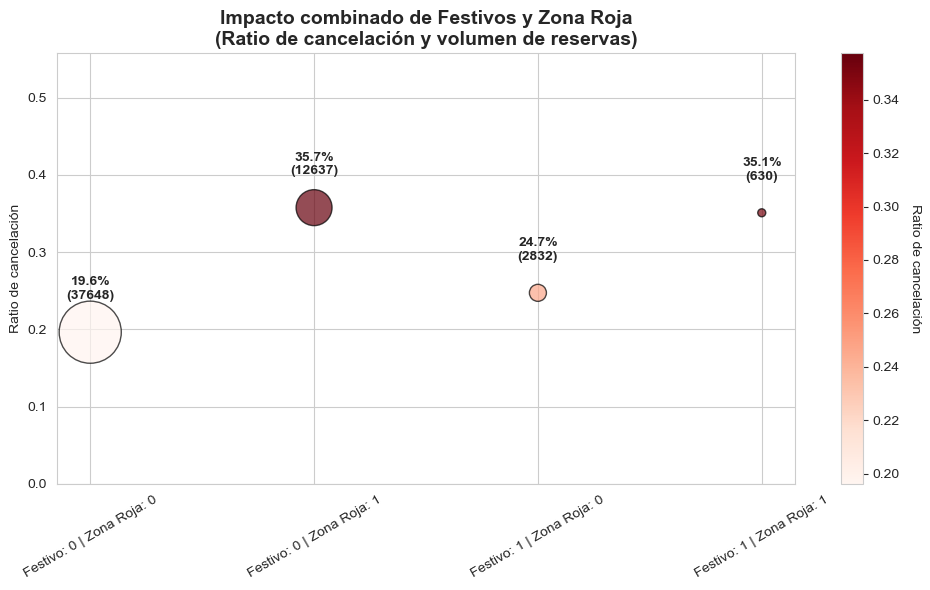

In [ ]:

# Agrupar por festivo y zona roja
festivo_group = (
    df.groupby(["estancia_en_festivo", "zona_roja_mes"])
    .agg(
        ratio_cancelacion=("status", lambda x: (x=="cancelled").mean()),
        reservas=("status", "count")
    )
    .reset_index()
)

# Crear etiquetas combinadas
festivo_group["grupo"] = (
    "Festivo: " + festivo_group["estancia_en_festivo"].astype(str) +
    " | Zona Roja: " + festivo_group["zona_roja_mes"].astype(str)
)

# Orden lógico
orden = ["Festivo: 0 | Zona Roja: 0",
         "Festivo: 0 | Zona Roja: 1",
         "Festivo: 1 | Zona Roja: 0",
         "Festivo: 1 | Zona Roja: 1"]
festivo_group["grupo"] = pd.Categorical(festivo_group["grupo"], categories=orden, ordered=True)

# Normalizar ratio para colormap
norm = Normalize(festivo_group["ratio_cancelacion"].min(), festivo_group["ratio_cancelacion"].max())
colors = plt.cm.Reds(norm(festivo_group["ratio_cancelacion"]))

# Tamaño burbuja proporcional a reservas
sizes = festivo_group["reservas"] / festivo_group["reservas"].max() * 2000  # ajustar escala

# Plot tipo burbuja
plt.figure(figsize=(10,6))
ax = plt.gca()

scatter = ax.scatter(
    x=festivo_group["grupo"],
    y=festivo_group["ratio_cancelacion"],
    s=sizes,
    c=festivo_group["ratio_cancelacion"],
    cmap="Reds",
    alpha=0.7,
    edgecolor="black"
)

# Etiquetas con número de reservas y % cancelación
for i, row in festivo_group.iterrows():
    ax.text(
        row["grupo"],
        row["ratio_cancelacion"] + 0.043,
        f"{row['ratio_cancelacion']*100:.1f}%\n({row['reservas']})",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylabel("Ratio de cancelación")
plt.ylim(0, festivo_group["ratio_cancelacion"].max() + 0.2)
plt.title("Impacto combinado de Festivos y Zona Roja\n(Ratio de cancelación y volumen de reservas)", fontsize=14, fontweight="bold")
plt.xticks(rotation=30)

# Colorbar para el ratio de cancelación
sm = ScalarMappable(cmap="Reds", norm=norm)
sm.set_array(festivo_group["ratio_cancelacion"])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Ratio de cancelación", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


In [ ]:
#INTERPRETACION:
# 1) La mayoria de las reservas de hacen en meses normales y no festivos. Ratio de cancelacion relativamente bajo.
# 2) Los meses de zona roja, aunque no sean festivos, tienen una alta probabilidad de cancelacion. Ratio alto, color muy rojo, auqnue volumne moderado.
# 3) Los festivos por si solos aumentan cancelaciones, pero no tanto como la zona roja. ratio medio, burbuja pequeña/ moderada.
# 4) La combinacion de festivo y zona roja tiene alta cancelacion, pero poca reservas totales. ratio alto, burbuja pequeña (pocas reservas)
#TAMAÑO: NUMERO DE RESERVAS


#CONCLUSION:
# Zona roja tiene mayor impacto en cancelacion que los festivos por si solos.
# festivos + zona roja. riesgo alto pero volumne bajo--> casos vriticos a vigilar
#La mayoría de reservas ocurre fuera de festivos y meses de zona roja, con bajo riesgo de cancelación.
# Este gráfico permite visualizar ratio y volumen al mismo tiempo, lo que ayuda a priorizar meses/condiciones de riesgo para intervención.


# Eje X → combinación Festivo / Zona Roja
# Eje Y → ratio de cancelación
# Tamaño de burbuja → número de reservas
# Color → intensidad de cancelación

14º GRAFICO: Distribución de adultos y niños por tipo de activo (GENERAL)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\1675079728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\1675079728.py:2: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.violinplot(


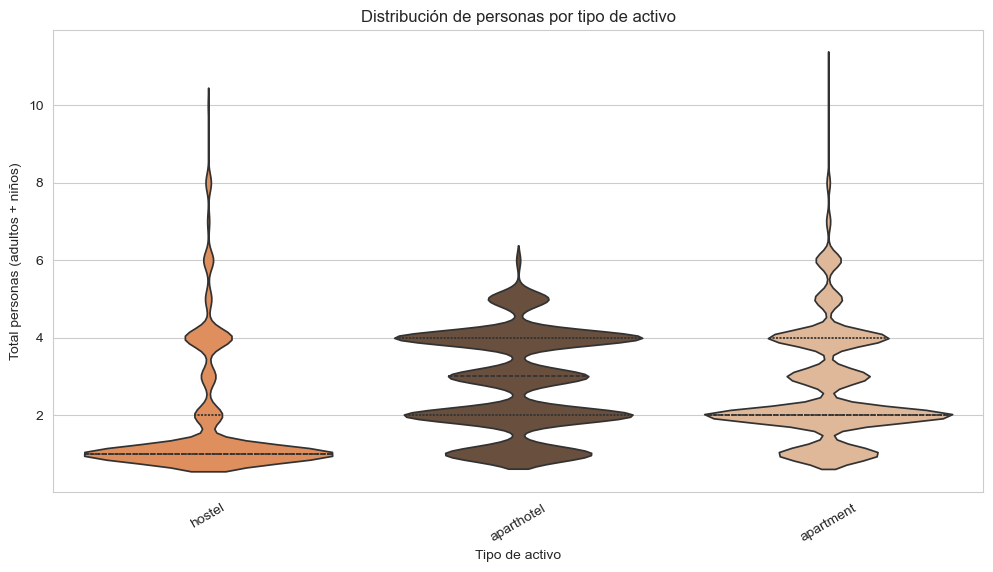

In [161]:
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df,
    x='asset_type',
    y='total_personas_adult_y_niños',
    palette=paleta,
    inner='quartile'
)
plt.title("Distribución de personas por tipo de activo")
plt.xlabel("Tipo de activo")
plt.ylabel("Total personas (adultos + niños)")
plt.xticks(rotation=30)
plt.show()


15º GRAFICO: Valor medio de reservas por segmento de negocio (GENERAL)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\338914875.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\338914875.py:8: UserWarning: 
The palette list has fewer values (5) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


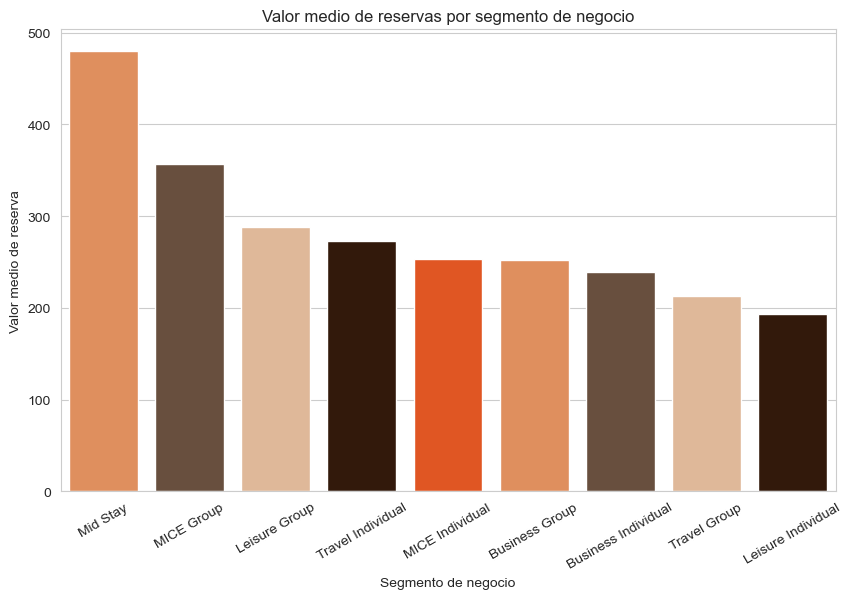

In [163]:
# Ordenar de mayor a menor
segment_group_sorted = segment_group.sort_values(
    by='reservation_net_value',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=segment_group_sorted,
    x='business_segment',
    y='reservation_net_value',
    palette=paleta
)
plt.title("Valor medio de reservas por segmento de negocio")
plt.xlabel("Segmento de negocio")
plt.ylabel("Valor medio de reserva")
plt.xticks(rotation=30)
plt.show()


16º GRAFICO: Duración media de estancia por ciudad y tipo de activo (GENERAL)

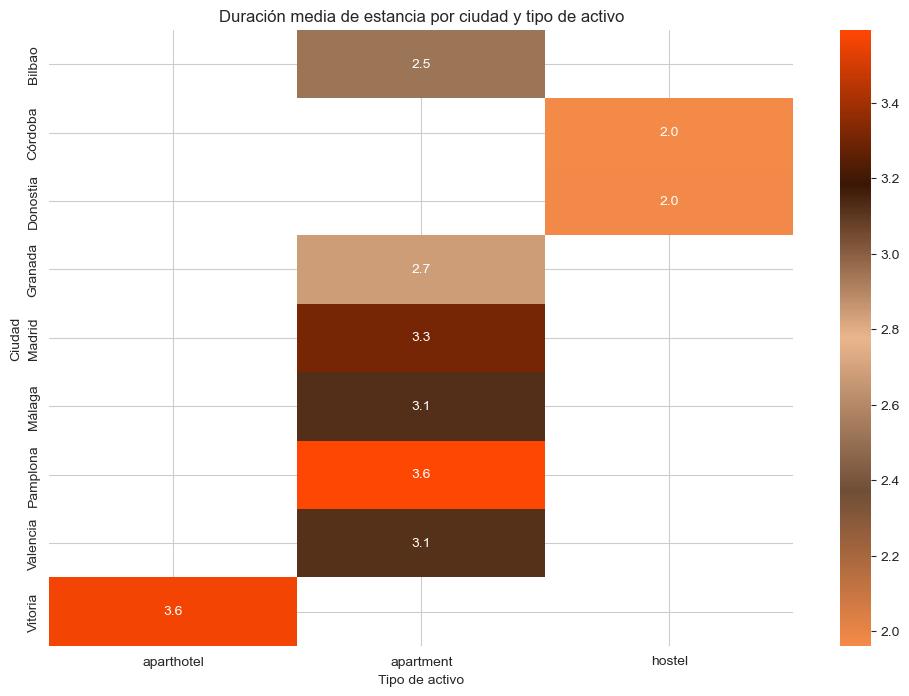

In [166]:
pivot = df.pivot_table(
    values='lenght_of_stay',
    index='City',
    columns='asset_type',
    aggfunc='mean'
)
plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap=LinearSegmentedColormap.from_list("custom_palette", paleta)
)
plt.title("Duración media de estancia por ciudad y tipo de activo")
plt.ylabel("Ciudad")
plt.xlabel("Tipo de activo")
plt.show()


17º GRAFICO: Reservas según agencia de viajes (GENERAL)

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\3084938989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\3084938989.py:5: UserWarning: 
The palette list has fewer values (5) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


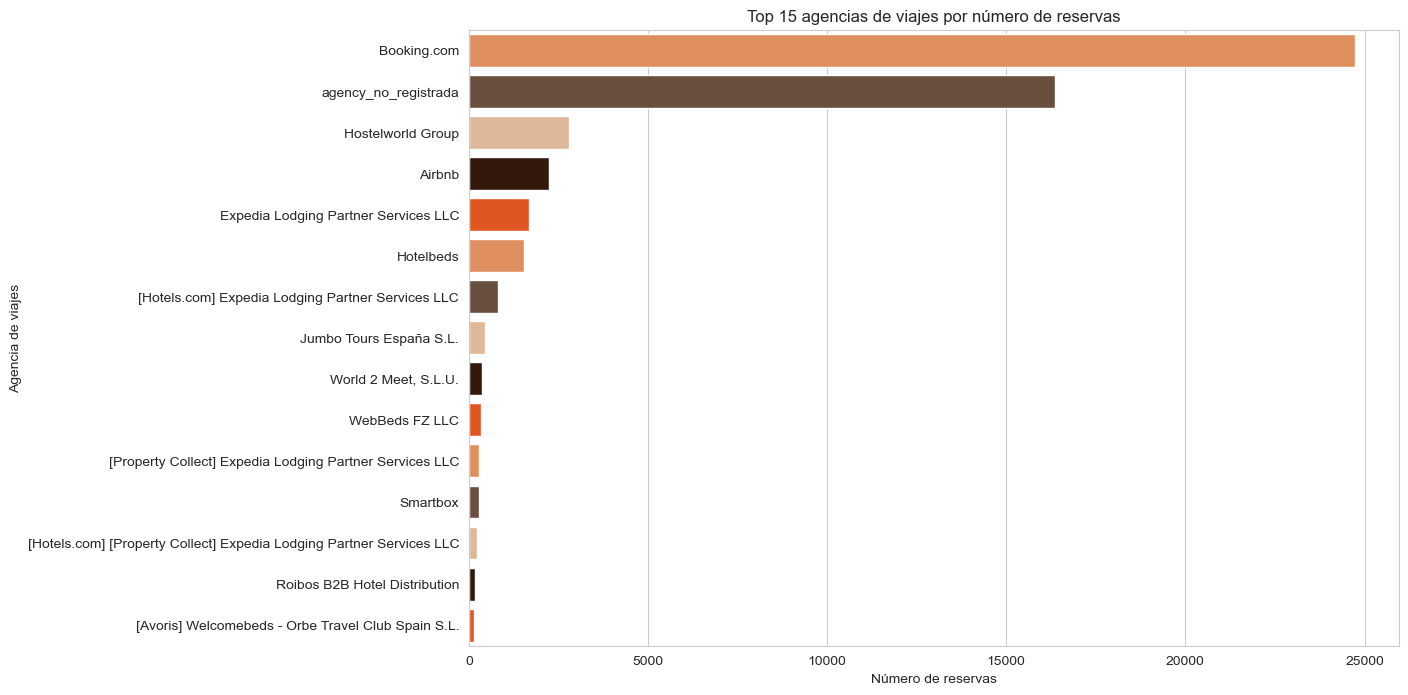

In [167]:
agency_group = df['travel_agency_name'].value_counts().reset_index()
agency_group.columns = ['travel_agency_name', 'reservas']

plt.figure(figsize=(12,8))
sns.barplot(
    data=agency_group.head(15),
    y='travel_agency_name',
    x='reservas',
    palette=paleta
)
plt.title("Top 15 agencias de viajes por número de reservas")
plt.xlabel("Número de reservas")
plt.ylabel("Agencia de viajes")
plt.show()


# CANCELACIÓN

18º GRAFICO: Lead time vs ratio de cancelación

C:\Users\Larau\AppData\Local\Temp\ipykernel_39156\716707621.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lead_cancel = df.groupby('lead_time').apply(lambda x: (x['status']=="cancelled").mean()).reset_index(name='ratio_cancelacion')


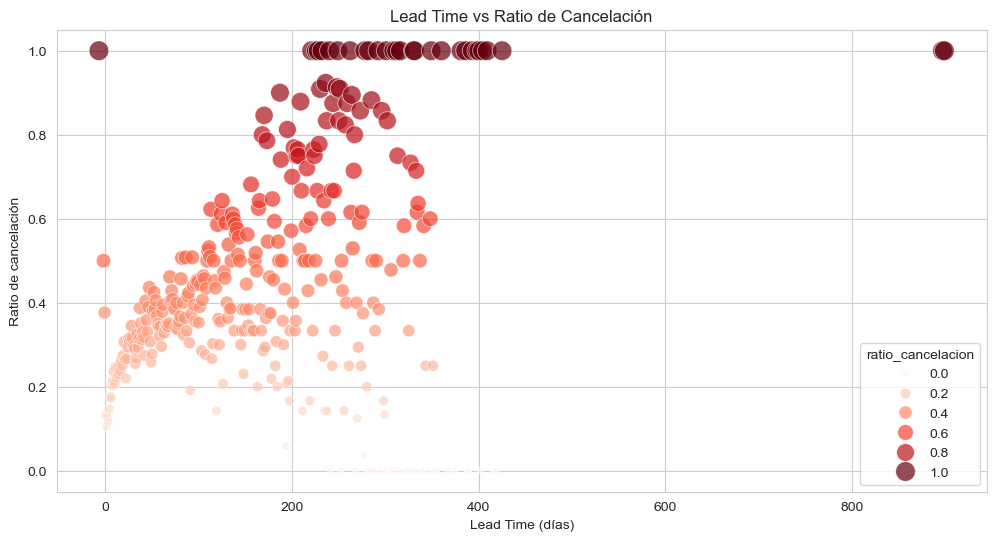

In [169]:
lead_cancel = df.groupby('lead_time').apply(lambda x: (x['status']=="cancelled").mean()).reset_index(name='ratio_cancelacion')

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=lead_cancel,
    x='lead_time',
    y='ratio_cancelacion',
    size='ratio_cancelacion',
    hue='ratio_cancelacion',
    palette='Reds',
    sizes=(20,200),
    alpha=0.7
)
plt.title("Lead Time vs Ratio de Cancelación")
plt.xlabel("Lead Time (días)")
plt.ylabel("Ratio de cancelación")
plt.show()


19º GRAFICO: Cancelaciones por motivo y estacion de reserva

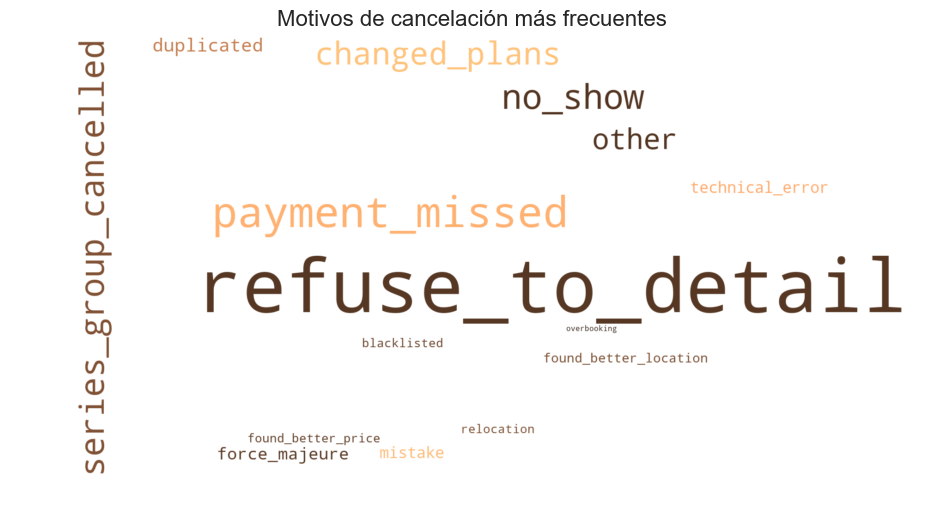

In [179]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar solo canceladas
cancel_reasons = df[df['status']=="cancelled"]['cancellation_reason']

# Contar frecuencia de cada motivo
freq_dict = cancel_reasons.value_counts().to_dict()

# Crear Word Cloud optimizado
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='copper',
    collocations=False,       # evita juntar palabras repetidas
    prefer_horizontal=0.9,    # favorece orientación horizontal
    max_font_size=80,          # tamaño máximo de fuente
    max_words=100,             # número máximo de palabras
    scale=2,                   # mejora resolución y densidad
    margin=2                   # reduce espacio entre palabras
).generate_from_frequencies(freq_dict)

# Mostrar Word Cloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Motivos de cancelación más frecuentes", fontsize=16)
plt.show()
